# Curating samples from the xView 

- sample from promising images
- cross-check with existing annotations
- output for annotating the (missing label) 'road'


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from functools import partial

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geometry as sgeo
import src.sampling as ssam

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView-train_images-subset/'
label_path = '../data/xView/labels-0/'
resolution = 128

out_path = '../data/xView/images-0/'
out_label_path = '../data/xView/labels-0.csv'

In [5]:
def combo_string(x):
    if x['roads'] == -1:
        return ''
    else:
        return str(x['buildings'])+str(x['roads'])+str(x['cars'])

def combine_labels( folder, res= 128, add_unlabelled= False):
    label_files = os.listdir( folder)
    assert all([f.endswith('.csv') for f in label_files])
    df = pd.DataFrame()
    for file in label_files:
        df_ = pd.read_csv(f'{folder}{file}')
        to_drop = df_.loc[ df_['labels'] == 'reject'].index
        df_.drop( labels= to_drop, inplace= True)
        df_['buildings'] = (df_['built_area'] / (res**2) > 0.25).astype(int)
        df_['cars'] = (df_['n_cars'] + df_['n_bus_trucks'] > 0).astype(int)
        df_['roads'] = df_['roads'].fillna(0).astype(int)
        #df_['B_R_C'] = df_.apply( lambda x: f'{x.buildings}{x.roads}{x.cars}', axis= 1)
        print(f'File {file}, keeping {len(df_)} entries.')
        df = pd.concat([df,df_])
    df['bbox_np'] = df['bbox_np'].map( lambda x: [int(y.strip('[]')) for y in x.split(',')])
    df['im_source'] = df.im_name.str.split('for_tiff').map( lambda x: x[0]).str.split('_').map( lambda x: x[0])
    df['image'] = 'tif' + df['im_source'] + '_x' + df['xs'].astype(str) + '_y' + df['ys'].astype(str) + '.png'
    df.loc[ df['labels']=='unlabel',['buildings','roads','cars']] = -1, -1, -1
    df['B_R_C'] = df.apply( combo_string, axis= 1)
    df.reset_index( inplace= True, drop= True)
    return df

def add_unlabelled_safe( dfs, im_dims, im_name, res= 128):
    """
    This assumes dfs is a slice of the larger frame.
    """
    n_lab = len( dfs.loc[ dfs['roads']>= 0])
    cols_output = ['image','xs','ys','bbox_np','buildings','roads','cars']
    df_new = dfs[['xs','ys']].copy()
    # offset and add jitter:
    df_new['xs'] += 40 + np.random.uniform(1,5,len(df_new))
    df_new['ys'] += 60 + np.random.uniform(2,10,len(df_new))
    df_new['bbox_np'] = df_new.apply(
        lambda x: ssam.square_bbox_around( x['xs'], x['ys'], res= res), axis= 1
    ).map(
        lambda x: [int(y) for y in x]
    )
    df_new[['buildings','roads','cars']] = -1,-1,-1
    df_new['image'] = df_new.apply( lambda x: ssam.name_sample_image( im_name, x['xs'], x['ys']), axis= 1)
    df_add = ssam.prep_samples_unlabelled(
        im_dims, im_name, n_lab, res, int(im_name), shift_min= 30
    )
    dfs_ = pd.concat([dfs[cols_output],df_add,df_new])
    dfs_.reset_index( drop=True, inplace=True)
    dfs_.sort_values(by=['xs','ys'],inplace=True)
    dfs_ = ssam.filter_xy( dfs_, int( res/ 5))
    n_lab_new = len( dfs_.loc[ dfs_['roads'] >=0])
    try:
        assert n_lab_new == n_lab
    except AssertionError:
        print(f'Lost {n_lab - n_lab_new} labels')
    return dfs_

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [6]:
df = combine_labels( label_path)
df.shape

File for_tiff102.csv, keeping 411 entries.
File for_tiff1037.csv, keeping 142 entries.
File for_tiff104.csv, keeping 117 entries.
File for_tiff105.csv, keeping 113 entries.
File for_tiff1051.csv, keeping 225 entries.
File for_tiff106.csv, keeping 287 entries.
File for_tiff1063.csv, keeping 169 entries.
File for_tiff1065.csv, keeping 104 entries.
File for_tiff107.csv, keeping 249 entries.
File for_tiff109.csv, keeping 351 entries.
File for_tiff110.csv, keeping 147 entries.
File for_tiff1121.csv, keeping 315 entries.
File for_tiff1124.csv, keeping 228 entries.
File for_tiff1132.csv, keeping 145 entries.


(3003, 16)

In [7]:
df_ = df.loc[ df['labels'] != 'unlabel']
df_.shape

(2293, 16)

<Axes: xlabel='B_R_C'>

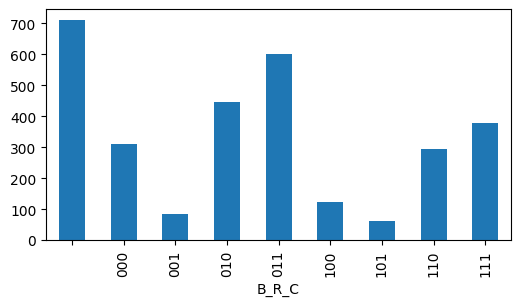

In [8]:
_, ax = plt.subplots( figsize= (6,3))
df.groupby('B_R_C').count()['xs'].plot(kind='bar', ax= ax)

Now that we have some high-level understanding can choose poss interesting images

In [72]:
im_src_loaded = None
for bbox_, name_, im_src_ in zip(df['bbox_np'][:3], df['image'][:3], df['im_source'][:3]):
    if im_src_loaded != im_src_:
        im_src_loaded = f'{data_path}{im_src_}.tif'
        image_ = np.array( Image.open( im_src_loaded))
        xmax, ymax, _ = image_.shape
        dfs = df.loc[ df['im_source'] == im_src_]
    
    #Image.fromarray( sgeo.crop_to_bbox( image_, bbox_)).save( f'{out_path}{name_}')

In [9]:
start = tm.time()

df_out = pd.DataFrame()
for im_src_ in df['im_source'].unique():
    im_src_path = f'{data_path}{im_src_}.tif'
    print(f'Loading {im_src_path}')
    image_ = np.array( Image.open( im_src_path))
    xmax, ymax, _ = image_.shape
    dfs = df.loc[ df['im_source'] == im_src_]
    dfs_ = add_unlabelled_safe( dfs, (xmax, ymax), im_src_, res= resolution)
    df_out = pd.concat( [df_out, dfs_])
    for bbox_, name_ in zip( dfs_['bbox_np'], dfs_['image']):
        Image.fromarray( sgeo.crop_to_bbox( image_, bbox_)).save( f'{out_path}{name_}')
    
df_out.reset_index( drop= True, inplace= True)
df_out['B_R_C'] = df_out.apply( combo_string, axis= 1)

df_out.to_csv( out_label_path, index= False)

print(f'\nTook {np.round((tm.time()-start)/60,3)} mins, output {len(df_out)} images.')
len(df_out.loc[ df_out['B_R_C']!='']), len(df_out)

Loading ../data/xView-train_images-subset/102.tif
Lost 1 labels
Loading ../data/xView-train_images-subset/1037.tif
Loading ../data/xView-train_images-subset/104.tif
Loading ../data/xView-train_images-subset/105.tif
Loading ../data/xView-train_images-subset/1051.tif
Loading ../data/xView-train_images-subset/106.tif
Loading ../data/xView-train_images-subset/1063.tif
Lost 4 labels
Loading ../data/xView-train_images-subset/1065.tif
Lost 3 labels
Loading ../data/xView-train_images-subset/107.tif
Loading ../data/xView-train_images-subset/109.tif
Loading ../data/xView-train_images-subset/110.tif
Lost 1 labels
Loading ../data/xView-train_images-subset/1121.tif
Loading ../data/xView-train_images-subset/1124.tif
Loading ../data/xView-train_images-subset/1132.tif
Lost 1 labels

Took 1.079 mins, output 8172 images.


(2283, 8172)

<Axes: xlabel='B_R_C'>

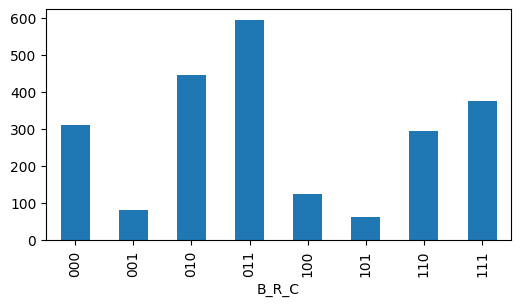

In [10]:
_, ax = plt.subplots( figsize= (6,3))
dfg = df_out.groupby('B_R_C').count()['xs']
dfg.loc[ dfg.index != ''].plot(kind='bar', ax= ax)

In [13]:
len(df_out['image'].unique()) == len(df_out)

True

In [16]:
set(df_out['image'].unique()) == set(os.listdir( out_path))

True